# DSAR Extractor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/dsar-extractor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/dsar-extractor/demo.ipynb)

> A subject access request arrives with one email address. Finding the rows is easy. Finding
> *all* of them, and *only* them, is the actual job - and getting it wrong fails in two
> opposite directions, both of which are breaches.

**What this covers**

1. The request, and the four things wrong with `WHERE email = ?`
2. One person, many keys - identity resolution with an evidence trail
3. **Abstention**: the weak link the tool refuses to join on, and what including it would have disclosed
4. Scope: why following every foreign key hands over the product catalog
5. Third-party withholding - Art. 15(4), the clause that makes a disclosure a breach
6. The rows no key join reaches at all
7. Access is not erasure: what you must disclose but may not delete
8. Measured: under-collection, over-collection, and the retention wall
9. Try your own subject map

*Fully offline - the 11-table warehouse is generated, no database and no real personal data.*

## 1. The request

> *"Please provide a copy of all personal data you hold about me. My email is
> `amara.osei@example.com`."*

Eleven tables. The obvious query is one line:

```sql
SELECT * FROM customers WHERE email = 'amara.osei@example.com';
```

Four separate things are wrong with it, and each one has a name in the regulation.
Start with the smallest: the address is not stored the way it was typed.

In [1]:
import re

def normalize_email(value):
    """Case-fold and strip plus-addressing - both are the same mailbox everywhere."""
    value = value.strip().lower()
    if "@" not in value:
        return value
    local, _, domain = value.partition("@")
    return f"{local.split('+', 1)[0]}@{domain}"

requested = "amara.osei@example.com"
stored = [
    "Amara.Osei@Example.com",          # customers.email, display-cased at signup
    "amara.osei+support@example.com",  # support_tickets, she tags her own mail
    "amara.osei+shop@example.com",     # support_tickets, a different tag
    "amara.osei@example.com",          # marketing_contacts, lowercased on import
]

print(f"{'stored spelling':<34} {'== requested?':<14} same mailbox?")
print("-" * 66)
for value in stored:
    exact = value == requested
    same = normalize_email(value) == normalize_email(requested)
    print(f"{value:<34} {str(exact):<14} {same}")

stored spelling                    == requested?  same mailbox?
------------------------------------------------------------------
Amara.Osei@Example.com             False          True
amara.osei+support@example.com     False          True
amara.osei+shop@example.com        False          True
amara.osei@example.com             True           True


Three of the four are the same mailbox and would not match. A case-insensitive
comparison rescues one of them. Nothing about `=` rescues the plus-addressed pair.

One caution, because the fix has a failure mode of its own: this normalizer does **not**
strip dots from the local part. Dot-insensitivity is a Gmail convention. Apply it to a
corporate domain and you have just merged two different employees into one data subject -
and the DSAR response now mails one person's records to the other.

In [2]:
print("gmail convention applied to a corporate domain:")
print("  a.osei@corp.example  vs  aosei@corp.example")
print("  -> two different people. Do not merge them.")
print()
print("what this normalizer does:", normalize_email("A.Osei+billing@Corp.Example"))

gmail convention applied to a corporate domain:
  a.osei@corp.example  vs  aosei@corp.example
  -> two different people. Do not merge them.

what this normalizer does: a.osei@corp.example


## 2. One person, many keys

The subject exists in the warehouse under four key shapes: an email (in three spellings),
a `customer_id`, a phone number, and two `anon_id` values from before she ever logged in.

Resolution walks these outward from the seed and records **why** each key is believed to
be the same person. That evidence column is not decoration - a DSAR response has to be
defensible, and "the join found it" is not a defence.

Here is the whole engine. It is plain Python: no database, no network, no dependencies
beyond the standard library.

In [3]:
"""DSAR extractor: resolve a data subject across a warehouse, disclose only what is theirs.

Four mechanisms, in the order they matter:

1. IDENTITY RESOLUTION - one person is many keys (case variants, plus-addressing,
   pre-login anonymous ids). An exact-match WHERE clause under-collects.
2. ABSTENTION - weak links (same name, same household) are NOT auto-included.
   Over-resolving discloses a different person's data to the requester, which is
   the same breach in the opposite direction.
3. SCOPE CLASSIFICATION - following every foreign key outward pulls in the product
   catalog, which is not personal data about anyone. Each edge is declared as
   subject-scoped or reference.
4. THIRD-PARTY WITHHOLDING - shared rows (a ticket thread, a referral, a gift order)
   contain another living person. Art. 15(4) / PDPA s.21(3): the copy must not
   adversely affect the rights of others. Ship it raw and the disclosure is a breach.

Plus: access is not erasure. Rows you must disclose under Art. 15 may be rows you
cannot delete under Art. 17, because a statutory retention period outranks the
erasure right. The plan says which, and on what basis.

No database, no network. Corpus is generated deterministically.
"""

from __future__ import annotations

import random
import re
from dataclasses import dataclass, field
from datetime import date, timedelta
from typing import Dict, List, Optional, Sequence, Set, Tuple

Row = Dict[str, object]
Corpus = Dict[str, List[Row]]

TODAY = date(2026, 8, 3)


# --------------------------------------------------------------------------------------
# 1. Identity
# --------------------------------------------------------------------------------------

EMAIL_RE = re.compile(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}")


def normalize_email(value: str) -> str:
    """Case-fold and strip plus-addressing. Both are the same mailbox at every major provider.

    Deliberately does NOT strip dots: that is a Gmail-only convention, and applying it to
    a corporate domain merges two different people. Under-normalizing loses rows; this
    particular over-normalization discloses someone else's.
    """
    value = value.strip().lower()
    if "@" not in value:
        return value
    local, _, domain = value.partition("@")
    local = local.split("+", 1)[0]
    return f"{local}@{domain}"


@dataclass(frozen=True)
class ResolvedKey:
    """One identifier believed to belong to the subject, with why we believe it."""

    key_type: str  # "email" | "customer_id" | "anon_id" | "phone"
    value: str
    strength: str  # "seed" | "exact" | "linked" | "weak"
    evidence: str

    @property
    def usable(self) -> bool:
        """Weak links are surfaced for a human, never joined on automatically."""
        return self.strength in ("seed", "exact", "linked")


@dataclass
class Identity:
    keys: List[ResolvedKey] = field(default_factory=list)
    # Raw stored spellings that normalized onto a subject mailbox. Not extra keys - the
    # same key written differently - but the audit log has to show them, because they are
    # exactly what the naive WHERE clause failed to match.
    variants: List[str] = field(default_factory=list)

    def add(self, key: ResolvedKey) -> bool:
        for existing in self.keys:
            if existing.key_type == key.key_type and existing.value == key.value:
                return False
        self.keys.append(key)
        return True

    def values(self, key_type: str, include_weak: bool = False) -> Set[str]:
        return {
            k.value
            for k in self.keys
            if k.key_type == key_type and (include_weak or k.usable)
        }

    @property
    def weak(self) -> List[ResolvedKey]:
        return [k for k in self.keys if not k.usable]


def resolve_identity(corpus: Corpus, seed_email: str) -> Identity:
    """Expand one seed identifier into every key the subject is known by.

    A real DSAR arrives with an email address and nothing else. The subject exists in
    the warehouse under at least four different key shapes.
    """
    ident = Identity()
    seed = normalize_email(seed_email)
    ident.add(ResolvedKey("email", seed, "seed", "supplied on the request form"))

    # Pass 1: every stored email that normalizes to a known mailbox is the same mailbox.
    for table, column in EMAIL_COLUMNS:
        for row in corpus[table]:
            raw = str(row.get(column) or "")
            if not raw:
                continue
            norm = normalize_email(raw)
            if norm not in ident.values("email"):
                continue
            ident.add(
                ResolvedKey(
                    "email", norm, "exact", f"{table}.{column} normalizes to the seed mailbox"
                )
            )
            if raw.strip() != norm:
                note = f"{table}.{column} = {raw!r} -> {norm}"
                if note not in ident.variants:
                    ident.variants.append(note)

    # Pass 2: customer records reachable from those mailboxes.
    for row in corpus["customers"]:
        if normalize_email(str(row["email"])) in ident.values("email"):
            ident.add(
                ResolvedKey(
                    "customer_id",
                    str(row["customer_id"]),
                    "exact",
                    f"customers.email = {row['email']!r}",
                )
            )
            if row.get("phone"):
                ident.add(
                    ResolvedKey(
                        "phone",
                        str(row["phone"]),
                        "exact",
                        f"customers.phone on {row['customer_id']}",
                    )
                )

    # Pass 3: controller-asserted device links. Deterministic, so joinable - but they are
    # an assertion the controller made, not a fact, which is why they are tagged 'linked'.
    for row in corpus["identity_links"]:
        if str(row["customer_id"]) in ident.values("customer_id"):
            ident.add(
                ResolvedKey(
                    "anon_id",
                    str(row["anon_id"]),
                    "linked",
                    f"identity_links: device stitched on {row['linked_at']} ({row['method']})",
                )
            )

    # Pass 4: weak candidates. Recorded, never joined on. Including these is how a
    # controller mails one person's order history to a stranger with the same name.
    subject_names = {
        str(r["full_name"]).lower()
        for r in corpus["customers"]
        if str(r["customer_id"]) in ident.values("customer_id")
    }
    for row in corpus["customers"]:
        if str(row["customer_id"]) in ident.values("customer_id"):
            continue
        if str(row["full_name"]).lower() in subject_names:
            ident.add(
                ResolvedKey(
                    "customer_id",
                    str(row["customer_id"]),
                    "weak",
                    f"same full_name {row['full_name']!r}, different mailbox "
                    f"({row['email']}) - needs a human decision",
                )
            )
    return ident


# --------------------------------------------------------------------------------------
# 2. The subject map
# --------------------------------------------------------------------------------------


@dataclass(frozen=True)
class KeyCol:
    column: str
    key_type: str
    role: str = "subject"  # "subject" identifies the row's owner; "counterparty" the other person


@dataclass(frozen=True)
class ScopedVia:
    """This table inherits subject scope from a parent row."""

    child_col: str
    parent_table: str
    parent_col: str


@dataclass(frozen=True)
class Retention:
    basis: str
    years: int
    date_col: str


@dataclass(frozen=True)
class TableSpec:
    name: str
    pk: str
    keys: Tuple[KeyCol, ...] = ()
    text_cols: Tuple[str, ...] = ()
    scoped_via: Optional[ScopedVia] = None
    category: str = "personal"  # "personal" | "reference"
    erasure: str = "delete"  # "delete" | "anonymize" | "redact"
    retention: Optional[Retention] = None
    fks: Tuple[Tuple[str, str, str], ...] = ()  # (col, target_table, target_col) - all of them


SUBJECT_MAP: Tuple[TableSpec, ...] = (
    TableSpec(
        "customers",
        "customer_id",
        keys=(
            KeyCol("email", "email"),
            KeyCol("customer_id", "customer_id"),
            KeyCol("phone", "phone"),
        ),
    ),
    TableSpec(
        "orders",
        "order_id",
        keys=(
            KeyCol("customer_id", "customer_id"),
            KeyCol("gift_recipient_email", "email", role="counterparty"),
        ),
        fks=(("customer_id", "customers", "customer_id"),),
        retention=Retention("Statutory: accounting records, 7 years", 7, "order_date"),
    ),
    TableSpec(
        "order_items",
        "order_item_id",
        scoped_via=ScopedVia("order_id", "orders", "order_id"),
        fks=(("order_id", "orders", "order_id"), ("product_id", "products", "product_id")),
        retention=Retention("Statutory: accounting records, 7 years", 7, "_order_date"),
    ),
    TableSpec(
        "payments",
        "payment_id",
        scoped_via=ScopedVia("order_id", "orders", "order_id"),
        fks=(("order_id", "orders", "order_id"),),
        retention=Retention("Statutory: tax and payment records, 7 years", 7, "paid_at"),
    ),
    TableSpec("products", "product_id", category="reference"),
    TableSpec(
        "support_tickets",
        "ticket_id",
        keys=(KeyCol("requester_email", "email"),),
        text_cols=("subject", "body"),
    ),
    TableSpec(
        "ticket_messages",
        "message_id",
        keys=(KeyCol("author_email", "email"),),
        text_cols=("body",),
        scoped_via=ScopedVia("ticket_id", "support_tickets", "ticket_id"),
        fks=(("ticket_id", "support_tickets", "ticket_id"),),
        erasure="redact",
    ),
    TableSpec(
        "marketing_contacts",
        "contact_id",
        keys=(KeyCol("email_lower", "email"),),
    ),
    TableSpec(
        "web_events",
        "event_id",
        keys=(KeyCol("customer_id", "customer_id"), KeyCol("anon_id", "anon_id")),
        fks=(("customer_id", "customers", "customer_id"),),
        erasure="anonymize",
    ),
    TableSpec(
        "identity_links",
        "link_id",
        keys=(KeyCol("customer_id", "customer_id"), KeyCol("anon_id", "anon_id")),
        fks=(("customer_id", "customers", "customer_id"),),
    ),
    TableSpec(
        "referrals",
        "referral_id",
        keys=(
            KeyCol("referrer_customer_id", "customer_id"),
            KeyCol("referee_email", "email"),
        ),
        erasure="redact",
    ),
)

SPEC_BY_NAME = {t.name: t for t in SUBJECT_MAP}

EMAIL_COLUMNS: Tuple[Tuple[str, str], ...] = tuple(
    (t.name, k.column) for t in SUBJECT_MAP for k in t.keys if k.key_type == "email"
)


# --------------------------------------------------------------------------------------
# 3. Extraction
# --------------------------------------------------------------------------------------

DIRECT = "direct"  # row carries a subject key
DERIVED = "derived"  # reached through a declared subject-scoped edge
MENTION = "mention"  # only free text names the subject; no key join reaches it


@dataclass
class Hit:
    table: str
    pk: str
    row: Row
    how: str  # DIRECT | DERIVED | MENTION
    reason: str
    third_parties: Tuple[str, ...] = ()

    @property
    def shared(self) -> bool:
        return bool(self.third_parties)


def _row_matches_subject(spec: TableSpec, row: Row, ident: Identity) -> Optional[str]:
    for key in spec.keys:
        if key.role != "subject":
            continue
        raw = row.get(key.column)
        if raw in (None, ""):
            continue
        value = normalize_email(str(raw)) if key.key_type == "email" else str(raw)
        if value in ident.values(key.key_type):
            return f"{spec.name}.{key.column} = {raw!r}"
    return None


def _third_parties(
    spec: TableSpec, row: Row, ident: Identity, others: Dict[str, str]
) -> Tuple[str, ...]:
    """Identifiers in this row that belong to a living person who is not the subject."""
    found: List[str] = []
    subject_emails = ident.values("email")
    subject_customers = ident.values("customer_id")

    for key in spec.keys:
        raw = row.get(key.column)
        if raw in (None, ""):
            continue
        if key.key_type == "email":
            norm = normalize_email(str(raw))
            if norm not in subject_emails and norm in others:
                found.append(f"{key.column}={raw}")
        elif key.key_type == "customer_id" and str(raw) not in subject_customers:
            found.append(f"{key.column}={raw}")

    for col in spec.text_cols:
        for match in EMAIL_RE.findall(str(row.get(col) or "")):
            norm = normalize_email(match)
            if norm not in subject_emails and norm in others:
                found.append(f"{col}~{match}")
    return tuple(dict.fromkeys(found))


def _mentions_subject(spec: TableSpec, row: Row, ident: Identity) -> Optional[str]:
    subject_emails = ident.values("email")
    for col in spec.text_cols:
        text = str(row.get(col) or "")
        for match in EMAIL_RE.findall(text):
            if normalize_email(match) in subject_emails:
                return f"free text {spec.name}.{col} contains {match!r}"
    return None


def _known_emails(corpus: Corpus) -> Dict[str, str]:
    """Every mailbox the controller holds a person behind, normalized -> display form."""
    known: Dict[str, str] = {}
    for row in corpus["customers"]:
        known[normalize_email(str(row["email"]))] = str(row["full_name"])
    for row in corpus["marketing_contacts"]:
        known.setdefault(normalize_email(str(row["email_lower"])), "marketing contact")
    return known


def extract(corpus: Corpus, ident: Identity) -> List[Hit]:
    """Everything the controller holds about this subject, and nothing only related to them."""
    others = _known_emails(corpus)
    hits: List[Hit] = []
    seen: Set[Tuple[str, str]] = set()

    def push(spec: TableSpec, row: Row, how: str, reason: str) -> None:
        pk = str(row[spec.pk])
        if (spec.name, pk) in seen:
            return
        seen.add((spec.name, pk))
        hits.append(Hit(spec.name, pk, row, how, reason, _third_parties(spec, row, ident, others)))

    # Pass A - direct key matches.
    for spec in SUBJECT_MAP:
        if spec.category == "reference":
            continue
        for row in corpus[spec.name]:
            reason = _row_matches_subject(spec, row, ident)
            if reason:
                push(spec, row, DIRECT, reason)

    # Pass B - inherit scope along declared subject-scoped edges, to a fixed point.
    for _ in range(len(SUBJECT_MAP)):
        added = False
        parents = {(h.table, h.pk) for h in hits}
        for spec in SUBJECT_MAP:
            if spec.scoped_via is None or spec.category == "reference":
                continue
            via = spec.scoped_via
            for row in corpus[spec.name]:
                if (spec.name, str(row[spec.pk])) in seen:
                    continue
                if (via.parent_table, str(row[via.child_col])) in parents:
                    before = len(hits)
                    push(
                        spec,
                        row,
                        DERIVED,
                        f"subject-scoped edge {spec.name}.{via.child_col} -> "
                        f"{via.parent_table}.{via.parent_col}",
                    )
                    added = added or len(hits) > before
        if not added:
            break

    # Pass C - free-text sweep. Rows about the subject that no key join reaches.
    for spec in SUBJECT_MAP:
        if spec.category == "reference" or not spec.text_cols:
            continue
        for row in corpus[spec.name]:
            if (spec.name, str(row[spec.pk])) in seen:
                continue
            reason = _mentions_subject(spec, row, ident)
            if reason:
                push(spec, row, MENTION, reason)

    return hits


# --------------------------------------------------------------------------------------
# 4. Baselines to measure against
# --------------------------------------------------------------------------------------


def naive_extract(corpus: Corpus, seed_email: str) -> Set[Tuple[str, str]]:
    """A competent-but-ordinary DSAR query: case-insensitive email match, then follow
    customer_id. This is what most controllers actually run."""
    target = seed_email.strip().lower()
    found: Set[Tuple[str, str]] = set()
    customer_ids: Set[str] = set()

    for table, column in EMAIL_COLUMNS:
        spec = SPEC_BY_NAME[table]
        for row in corpus[table]:
            if str(row.get(column) or "").strip().lower() == target:
                found.add((table, str(row[spec.pk])))
                if table == "customers":
                    customer_ids.add(str(row["customer_id"]))

    for spec in SUBJECT_MAP:
        if spec.category == "reference":
            continue
        if not any(k.column == "customer_id" for k in spec.keys):
            continue
        for row in corpus[spec.name]:
            if str(row.get("customer_id") or "") in customer_ids:
                found.add((spec.name, str(row[spec.pk])))

    # ... and the child tables of those orders, which the naive version does get right.
    order_ids = {pk for (t, pk) in found if t == "orders"}
    for name in ("order_items", "payments"):
        spec = SPEC_BY_NAME[name]
        for row in corpus[name]:
            if str(row["order_id"]) in order_ids:
                found.add((name, str(row[spec.pk])))
    return found


def naive_fk_sweep(corpus: Corpus, hits: Sequence[Hit]) -> Dict[str, int]:
    """Follow every foreign key outward from the included rows and count what arrives.

    This is the other common implementation: 'just traverse the schema graph'. It reaches
    the product catalog, which is not personal data about anybody.
    """
    index = {spec.name: {str(r[spec.pk]): r for r in corpus[spec.name]} for spec in SUBJECT_MAP}
    frontier = [(h.table, h.pk) for h in hits]
    seen = set(frontier)
    extra: Dict[str, Set[str]] = {}

    for _ in range(3):
        nxt: List[Tuple[str, str]] = []
        for table, pk in frontier:
            spec = SPEC_BY_NAME[table]
            row = index[table].get(pk)
            if row is None:
                continue
            for col, target, _target_col in spec.fks:
                value = row.get(col)
                if value in (None, ""):
                    continue
                tid = str(value)
                if (target, tid) in seen or tid not in index[target]:
                    continue
                seen.add((target, tid))
                nxt.append((target, tid))
                if SPEC_BY_NAME[target].category == "reference":
                    extra.setdefault(target, set()).add(tid)
        if not nxt:
            break
        frontier = nxt

    result = {t: len(v) for t, v in extra.items()}

    # The reverse join, for scale: one careless products -> order_items step.
    if "products" in extra:
        touched = [r for r in corpus["order_items"] if str(r["product_id"]) in extra["products"]]
        order_owner = {str(o["order_id"]): str(o["customer_id"]) for o in corpus["orders"]}
        result["_reverse_order_items"] = len(touched)
        result["_reverse_customers"] = len(
            {order_owner.get(str(r["order_id"])) for r in touched} - {None}
        )
    return result


def weak_link_cost(corpus: Corpus, ident: Identity) -> Dict[str, int]:
    """What auto-including the weak (same-name) links would have disclosed."""
    weak_ids = {k.value for k in ident.weak if k.key_type == "customer_id"}
    if not weak_ids:
        return {}
    orders = [r for r in corpus["orders"] if str(r["customer_id"]) in weak_ids]
    order_ids = {str(r["order_id"]) for r in orders}
    return {
        "other_people": len(weak_ids),
        "orders": len(orders),
        "payments": len([r for r in corpus["payments"] if str(r["order_id"]) in order_ids]),
        "order_items": len([r for r in corpus["order_items"] if str(r["order_id"]) in order_ids]),
    }


# --------------------------------------------------------------------------------------
# 5. Redaction and the disclosure pack
# --------------------------------------------------------------------------------------

WITHHELD = "[third party - withheld under Art. 15(4)]"


def redact(hit: Hit, ident: Identity, corpus: Corpus) -> Row:
    """Return a copy of the row safe to hand to the requester."""
    if not hit.shared:
        return dict(hit.row)

    spec = SPEC_BY_NAME[hit.table]
    others = _known_emails(corpus)
    out = dict(hit.row)
    subject_emails = ident.values("email")

    for key in spec.keys:
        raw = out.get(key.column)
        if raw in (None, ""):
            continue
        if key.key_type == "email":
            norm = normalize_email(str(raw))
            if norm not in subject_emails and norm in others:
                out[key.column] = WITHHELD
        elif key.key_type == "customer_id" and str(raw) not in ident.values("customer_id"):
            out[key.column] = WITHHELD

    for col in spec.text_cols:
        text = str(out.get(col) or "")
        if not text:
            continue
        for match in EMAIL_RE.findall(text):
            norm = normalize_email(match)
            if norm not in subject_emails and norm in others:
                text = text.replace(match, WITHHELD)
        out[col] = text
    return out


def disclosure_pack(corpus: Corpus, ident: Identity, hits: Sequence[Hit]) -> Dict[str, List[Row]]:
    pack: Dict[str, List[Row]] = {}
    for hit in hits:
        pack.setdefault(hit.table, []).append(redact(hit, ident, corpus))
    return pack


# --------------------------------------------------------------------------------------
# 6. Erasure plan - deliberately not the same set of rows
# --------------------------------------------------------------------------------------

DELETE = "delete"
ANONYMIZE = "anonymize"
REDACT_SUBJECT = "redact subject fields, keep row"
RETAIN = "retain - erasure blocked"


@dataclass
class ErasureAction:
    table: str
    pk: str
    action: str
    basis: str


def erasure_plan(hits: Sequence[Hit], corpus: Corpus, today: date = TODAY) -> List[ErasureAction]:
    order_date = {str(o["order_id"]): o["order_date"] for o in corpus["orders"]}
    plan: List[ErasureAction] = []

    for hit in hits:
        spec = SPEC_BY_NAME[hit.table]

        if spec.retention is not None:
            col = spec.retention.date_col
            when = (
                order_date.get(str(hit.row.get("order_id")))
                if col.startswith("_")
                else hit.row.get(col)
            )
            if isinstance(when, date) and when > today - timedelta(days=365 * spec.retention.years):
                until = when + timedelta(days=365 * spec.retention.years)
                plan.append(
                    ErasureAction(
                        hit.table,
                        hit.pk,
                        RETAIN,
                        f"{spec.retention.basis} - releases {until.isoformat()}",
                    )
                )
                continue

        if hit.shared:
            plan.append(
                ErasureAction(
                    hit.table,
                    hit.pk,
                    REDACT_SUBJECT,
                    "row is also another person's record - deleting it would erase their data",
                )
            )
        elif spec.erasure == ANONYMIZE:
            plan.append(
                ErasureAction(
                    hit.table,
                    hit.pk,
                    ANONYMIZE,
                    "null the identifier, keep the event for aggregates",
                )
            )
        elif hit.how == MENTION:
            plan.append(
                ErasureAction(
                    hit.table,
                    hit.pk,
                    REDACT_SUBJECT,
                    "subject appears only inside free text written by someone else",
                )
            )
        else:
            plan.append(ErasureAction(hit.table, hit.pk, DELETE, "no retention obligation"))
    return plan


# --------------------------------------------------------------------------------------
# 7. Deterministic corpus
# --------------------------------------------------------------------------------------

FIRST = ["Amara", "Ravi", "Mei", "Tomas", "Nadia", "Jonas", "Priya", "Ines", "Kofi", "Yuki"]
LAST = ["Osei", "Bakshi", "Lim", "Novak", "Haddad", "Berg", "Rao", "Costa", "Mensah", "Sato"]
CATEGORIES = ["kitchen", "outdoor", "audio", "lighting", "storage"]
SUBJECT_EMAIL = "amara.osei@example.com"


def build_corpus(seed: int = 7) -> Corpus:
    rng = random.Random(seed)
    customers: List[Row] = []

    # The subject. Stored with a display-cased mailbox - a case-sensitive WHERE misses it.
    customers.append(
        {
            "customer_id": "C0001",
            "full_name": "Amara Osei",
            "email": "Amara.Osei@Example.com",
            "phone": "+65 8100 4417",
            "created_at": date(2023, 3, 14),
        }
    )
    # A different living person with the same name. The reason weak links abstain.
    customers.append(
        {
            "customer_id": "C0047",
            "full_name": "Amara Osei",
            "email": "a.osei@other-example.com",
            "phone": "+65 9022 7781",
            "created_at": date(2024, 11, 2),
        }
    )
    # The three counterparties the subject is entangled with. Real customers, so the
    # third-party test has an actual person to protect rather than an unknown address.
    for cid, name, email in (
        ("C0012", "Jonas Berg", "jonas.berg12@example.com"),
        ("C0008", "Priya Rao", "priya.rao8@example.com"),
        ("C0021", "Yuki Sato", "yuki.sato21@example.com"),
    ):
        customers.append(
            {
                "customer_id": cid,
                "full_name": name,
                "email": email,
                "phone": f"+65 9{rng.randint(1000000, 9999999)}",
                "created_at": date(2023, 1, 1) + timedelta(days=rng.randint(0, 900)),
            }
        )

    taken = {str(c["customer_id"]) for c in customers}
    for i in range(2, 60):
        cid = f"C{i + 1:04d}"
        if cid in taken:
            continue
        first = rng.choice(FIRST)
        last = rng.choice(LAST)
        customers.append(
            {
                "customer_id": cid,
                "full_name": f"{first} {last}",
                "email": f"{first.lower()}.{last.lower()}{i}@example.com",
                "phone": f"+65 9{rng.randint(1000000, 9999999)}",
                "created_at": date(2023, 1, 1) + timedelta(days=rng.randint(0, 900)),
            }
        )

    products = [
        {
            "product_id": f"P{i:03d}",
            "name": f"{rng.choice(CATEGORIES).title()} item {i}",
            "category": rng.choice(CATEGORIES),
            "list_price": round(rng.uniform(8, 240), 2),
        }
        for i in range(1, 61)
    ]

    orders: List[Row] = []
    order_items: List[Row] = []
    payments: List[Row] = []
    oid = 0
    pmt = 0
    iid = 0

    def add_order(customer_id: str, when: date, gift: Optional[str] = None) -> str:
        nonlocal oid, pmt, iid
        oid += 1
        order_id = f"O{oid:05d}"
        total = 0.0
        for _ in range(rng.randint(1, 4)):
            iid += 1
            product = rng.choice(products)
            qty = rng.randint(1, 3)
            line = round(float(product["list_price"]) * qty, 2)
            total += line
            order_items.append(
                {
                    "order_item_id": f"OI{iid:05d}",
                    "order_id": order_id,
                    "product_id": product["product_id"],
                    "qty": qty,
                    "line_total": line,
                }
            )
        orders.append(
            {
                "order_id": order_id,
                "customer_id": customer_id,
                "order_date": when,
                "total": round(total, 2),
                "status": rng.choice(["fulfilled", "fulfilled", "refunded"]),
                "gift_recipient_email": gift,
            }
        )
        pmt += 1
        payments.append(
            {
                "payment_id": f"PM{pmt:05d}",
                "order_id": order_id,
                "amount": round(total, 2),
                "method": rng.choice(["card", "card", "paynow"]),
                "card_last4": f"{rng.randint(1000, 9999)}",
                "paid_at": when,
            }
        )
        return order_id

    # Subject's orders: some old enough to be erasable, some inside the 7-year hold.
    for when in [
        date(2018, 5, 9),
        date(2019, 2, 21),
        date(2023, 6, 30),
        date(2024, 4, 12),
        date(2025, 9, 3),
    ]:
        add_order("C0001", when)
    add_order("C0001", date(2025, 12, 20), gift="jonas.berg12@example.com")

    for customer in customers[1:]:
        for _ in range(rng.randint(1, 5)):
            add_order(
                str(customer["customer_id"]),
                date(2019, 1, 1) + timedelta(days=rng.randint(0, 2600)),
            )

    # Support: the subject writes in from a plus-addressed mailbox.
    support_tickets: List[Row] = [
        {
            "ticket_id": "T0001",
            "requester_email": "amara.osei+support@example.com",
            "subject": "Order O00003 arrived damaged",
            "body": "The lid was cracked on arrival. Photos attached.",
            "created_at": date(2023, 7, 2),
        },
        {
            "ticket_id": "T0002",
            "requester_email": "amara.osei+shop@example.com",
            "subject": "Change delivery address",
            "body": "Please redirect to the office address on file.",
            "created_at": date(2024, 4, 15),
        },
        {
            "ticket_id": "T0003",
            "requester_email": "Amara.Osei@Example.com",
            "subject": "Marketing emails",
            "body": "I would like to stop receiving the weekly newsletter.",
            "created_at": date(2025, 9, 10),
        },
    ]
    for i, customer in enumerate(customers[2:22], start=4):
        support_tickets.append(
            {
                "ticket_id": f"T{i:04d}",
                "requester_email": str(customer["email"]),
                "subject": f"Question about order {rng.randint(1, 90)}",
                "body": "Following up on my last message.",
                "created_at": date(2024, 1, 1) + timedelta(days=rng.randint(0, 600)),
            }
        )

    ticket_messages: List[Row] = [
        {
            "message_id": "M0001",
            "ticket_id": "T0001",
            "author_email": "amara.osei+support@example.com",
            "body": "Attaching two photos of the crack.",
            "sent_at": date(2023, 7, 2),
        },
        {
            "message_id": "M0002",
            "ticket_id": "T0001",
            "author_email": "support@shop.example",
            "body": "Replacement dispatched, tracking to follow.",
            "sent_at": date(2023, 7, 3),
        },
        {
            "message_id": "M0003",
            "ticket_id": "T0002",
            "author_email": "amara.osei+shop@example.com",
            "body": "Confirming the new address.",
            "sent_at": date(2024, 4, 15),
        },
        {
            "message_id": "M0004",
            "ticket_id": "T0003",
            "author_email": "support@shop.example",
            "body": "Unsubscribed. Confirmation sent to Amara.Osei@Example.com.",
            "sent_at": date(2025, 9, 10),
        },
        # A shared thread: another customer replies inside the subject's ticket.
        {
            "message_id": "M0005",
            "ticket_id": "T0002",
            "author_email": "jonas.berg12@example.com",
            "body": "I share this delivery slot - please keep my address unchanged.",
            "sent_at": date(2024, 4, 16),
        },
        # About the subject, but no key join reaches it: someone else's ticket, subject in the body.
        {
            "message_id": "M0006",
            "ticket_id": "T0009",
            "author_email": "priya.rao8@example.com",
            "body": "My colleague amara.osei@example.com placed this order on my behalf.",
            "sent_at": date(2024, 6, 1),
        },
        {
            "message_id": "M0007",
            "ticket_id": "T0014",
            "author_email": "support@shop.example",
            "body": "Escalated. Refund was actually issued to amara.osei@example.com in error.",
            "sent_at": date(2025, 2, 18),
        },
    ]
    for i, ticket in enumerate(support_tickets[3:], start=8):
        ticket_messages.append(
            {
                "message_id": f"M{i:04d}",
                "ticket_id": str(ticket["ticket_id"]),
                "author_email": str(ticket["requester_email"]),
                "body": "Thanks for the update.",
                "sent_at": ticket["created_at"],
            }
        )

    marketing_contacts: List[Row] = [
        {
            "contact_id": "MC001",
            "email_lower": "amara.osei@example.com",
            "consent": "withdrawn",
            "source": "checkout opt-in 2023-03-14",
        }
    ]
    for i, customer in enumerate(customers[1:40], start=2):
        marketing_contacts.append(
            {
                "contact_id": f"MC{i:03d}",
                "email_lower": str(customer["email"]).lower(),
                "consent": rng.choice(["granted", "granted", "withdrawn"]),
                "source": "checkout opt-in",
            }
        )

    identity_links: List[Row] = [
        {
            "link_id": "L001",
            "anon_id": "anon-9f3c21",
            "customer_id": "C0001",
            "linked_at": date(2023, 3, 14),
            "method": "login on same device",
        },
        {
            "link_id": "L002",
            "anon_id": "anon-4b70de",
            "customer_id": "C0001",
            "linked_at": date(2024, 4, 11),
            "method": "email click-through",
        },
    ]
    for i, customer in enumerate(customers[1:25], start=3):
        identity_links.append(
            {
                "link_id": f"L{i:03d}",
                "anon_id": f"anon-{rng.randrange(16 ** 6):06x}",
                "customer_id": str(customer["customer_id"]),
                "linked_at": date(2024, 1, 1) + timedelta(days=rng.randint(0, 500)),
                "method": "login on same device",
            }
        )

    web_events: List[Row] = []
    ev = 0
    for _ in range(22):  # logged in
        ev += 1
        web_events.append(
            {
                "event_id": f"E{ev:05d}",
                "anon_id": None,
                "customer_id": "C0001",
                "path": rng.choice(["/cart", "/product/P012", "/account", "/checkout"]),
                "ts": date(2024, 1, 1) + timedelta(days=rng.randint(0, 800)),
            }
        )
    for anon in ("anon-9f3c21", "anon-4b70de"):  # pre-login, same person
        for _ in range(7):
            ev += 1
            web_events.append(
                {
                    "event_id": f"E{ev:05d}",
                    "anon_id": anon,
                    "customer_id": None,
                    "path": rng.choice(["/", "/search", "/product/P031"]),
                    "ts": date(2023, 3, 1) + timedelta(days=rng.randint(0, 400)),
                }
            )
    for customer in customers[1:30]:
        for _ in range(rng.randint(1, 6)):
            ev += 1
            web_events.append(
                {
                    "event_id": f"E{ev:05d}",
                    "anon_id": None,
                    "customer_id": str(customer["customer_id"]),
                    "path": "/",
                    "ts": date(2024, 6, 1) + timedelta(days=rng.randint(0, 400)),
                }
            )

    referrals: List[Row] = [
        {
            "referral_id": "R001",
            "referrer_customer_id": "C0001",
            "referee_email": "yuki.sato21@example.com",
            "created_at": date(2024, 2, 3),
            "reward": "SGD 10",
        },
        {
            "referral_id": "R002",
            "referrer_customer_id": "C0019",
            "referee_email": "amara.osei@example.com",
            "created_at": date(2023, 3, 10),
            "reward": "SGD 10",
        },
    ]
    for i, customer in enumerate(customers[3:18], start=3):
        referrals.append(
            {
                "referral_id": f"R{i:03d}",
                "referrer_customer_id": str(customer["customer_id"]),
                "referee_email": str(rng.choice(customers)["email"]).lower(),
                "created_at": date(2024, 1, 1) + timedelta(days=rng.randint(0, 500)),
                "reward": "SGD 10",
            }
        )

    return {
        "customers": customers,
        "orders": orders,
        "order_items": order_items,
        "payments": payments,
        "products": products,
        "support_tickets": support_tickets,
        "ticket_messages": ticket_messages,
        "marketing_contacts": marketing_contacts,
        "web_events": web_events,
        "identity_links": identity_links,
        "referrals": referrals,
    }


# --------------------------------------------------------------------------------------
# 8. Reporting
# --------------------------------------------------------------------------------------


def coverage(corpus: Corpus, hits: Sequence[Hit], seed_email: str = SUBJECT_EMAIL) -> Dict[str, int]:
    naive = naive_extract(corpus, seed_email)
    full = {(h.table, h.pk) for h in hits}
    return {
        "naive": len(naive),
        "resolved": len(full),
        "missed_by_naive": len(full - naive),
        "mention_only": len([h for h in hits if h.how == MENTION]),
        "shared": len([h for h in hits if h.shared]),
    }


def summarize(corpus: Corpus, ident: Identity, hits: Sequence[Hit]) -> str:
    lines: List[str] = []
    cov = coverage(corpus, hits)
    lines.append("IDENTITY")
    for key in ident.keys:
        flag = " " if key.usable else "!"
        lines.append(f" {flag} {key.strength:<7} {key.key_type:<12} {key.value:<34} {key.evidence}")
    if ident.variants:
        lines.append("")
        lines.append("STORED SPELLINGS OF THE SAME MAILBOX (what an exact match misses)")
        for note in ident.variants:
            lines.append(f"   {note}")
    lines.append("")
    lines.append("COVERAGE")
    lines.append(f"   naive query found         {cov['naive']:>4} rows")
    lines.append(f"   resolved extract found    {cov['resolved']:>4} rows")
    lines.append(f"   missed by naive           {cov['missed_by_naive']:>4} rows")
    lines.append(f"   reachable only by text    {cov['mention_only']:>4} rows")
    lines.append(f"   shared with a third party {cov['shared']:>4} rows (redacted before disclosure)")
    lines.append("")
    lines.append("PER TABLE")
    by_table: Dict[str, List[Hit]] = {}
    for hit in hits:
        by_table.setdefault(hit.table, []).append(hit)
    for table in sorted(by_table):
        group = by_table[table]
        how: Dict[str, int] = {}
        for hit in group:
            how[hit.how] = how.get(hit.how, 0) + 1
        detail = ", ".join(f"{k}={v}" for k, v in sorted(how.items()))
        shared = sum(1 for h in group if h.shared)
        suffix = f", {shared} redacted" if shared else ""
        lines.append(f"   {table:<20} {len(group):>4}  ({detail}{suffix})")
    return "\n".join(lines)


### Build the warehouse and resolve the subject

Eleven tables, deterministic, no real personal data.

In [4]:
corpus = build_corpus()

print(f"{'table':<20} {'rows':>6}   scope")
print("-" * 44)
for spec in SUBJECT_MAP:
    print(f"{spec.name:<20} {len(corpus[spec.name]):>6}   {spec.category}")
print(f"\n{sum(len(v) for v in corpus.values()):>26} rows total")

table                  rows   scope
--------------------------------------------
customers                59   personal
orders                  156   personal
order_items             407   personal
payments                156   personal
products                 60   reference
support_tickets          23   personal
ticket_messages          27   personal
marketing_contacts       40   personal
web_events              136   personal
identity_links           26   personal
referrals                17   personal

                      1107 rows total


In [5]:
ident = resolve_identity(corpus, SUBJECT_EMAIL)

print("RESOLVED IDENTITY\n")
print(f"{'use':<22} {'strength':<9} {'key_type':<12} {'value':<26} evidence")
print("-" * 122)
for key in ident.keys:
    use = "join" if key.usable else "HOLD - human decision"
    print(f"{use:<22} {key.strength:<9} {key.key_type:<12} {key.value:<26} {key.evidence}")

print("\nSTORED SPELLINGS OF THE SAME MAILBOX")
for note in ident.variants:
    print(f"   {note}")

RESOLVED IDENTITY

use                    strength  key_type     value                      evidence
--------------------------------------------------------------------------------------------------------------------------
join                   seed      email        amara.osei@example.com     supplied on the request form
join                   exact     customer_id  C0001                      customers.email = 'Amara.Osei@Example.com'
join                   exact     phone        +65 8100 4417              customers.phone on C0001
join                   linked    anon_id      anon-9f3c21                identity_links: device stitched on 2023-03-14 (login on same device)
join                   linked    anon_id      anon-4b70de                identity_links: device stitched on 2024-04-11 (email click-through)
HOLD - human decision  weak      customer_id  C0047                      same full_name 'Amara Osei', different mailbox (a.osei@other-example.com) - needs a human decision

STOR

Two things worth pausing on.

**The `anon_id` keys are tagged `linked`, not `exact`.** They come from a device-stitching
table - a claim the controller made, not an observed fact. They are deterministic enough to
join on, but the strength label is what lets a reviewer challenge them later.

**One key is on hold.** Which brings us to the mechanism most extractors skip.

## 3. Abstention: the link the tool refuses to use

There is a second Amara Osei in the customer table. Same name, different mailbox, different
person. Every fuzzy identity-resolution library on the shelf will happily match them.

In [6]:
same_name = [c for c in corpus["customers"] if c["full_name"] == "Amara Osei"]
for row in same_name:
    print(f"{row['customer_id']}  {row['full_name']:<14} {row['email']:<30} joined {row['created_at']}")

print()
for key in ident.weak:
    print(f"HELD BACK: {key.key_type}={key.value}")
    print(f"           {key.evidence}")

C0001  Amara Osei     Amara.Osei@Example.com         joined 2023-03-14
C0047  Amara Osei     a.osei@other-example.com       joined 2024-11-02

HELD BACK: customer_id=C0047
           same full_name 'Amara Osei', different mailbox (a.osei@other-example.com) - needs a human decision


The tool records the candidate and refuses to join on it. Here is the cost of the
alternative - what an automatic name match would have posted to the requester:

In [7]:
cost = weak_link_cost(corpus, ident)
print("If the weak link had been auto-included, this DSAR response would have contained:\n")
for k, v in cost.items():
    if k != "other_people":
        print(f"   {v:>3} {k}")
print(f"\n...belonging to {cost['other_people']} completely different person.")
print("\nUnder-collection annoys the requester. Over-resolution is a personal data breach.")

If the weak link had been auto-included, this DSAR response would have contained:

     3 orders
     3 payments
     8 order_items

...belonging to 1 completely different person.

Under-collection annoys the requester. Over-resolution is a personal data breach.


## 4. Scope: relatedness is not aboutness

Now the traversal. The subject's orders are hers, so the line items on those orders are
hers too - that is a **subject-scoped** edge, declared in the map:

```python
TableSpec("order_items", "order_item_id",
          scoped_via=ScopedVia("order_id", "orders", "order_id"))
```

But `order_items.product_id` points at the product catalog, and a product row is not
personal data about anybody. It is *reachable* from her data, which is a different claim.
That edge is declared `reference` and the walk stops there.

Watch what happens when it does not.

In [8]:
hits = extract(corpus, ident)
sweep = naive_fk_sweep(corpus, hits)

print("Following every foreign key outward from her rows also collects:\n")
print(f"   {sweep['products']:>4} product rows   (not personal data about anyone)")
print()
print("And one step further - joining those products back to order_items:\n")
print(f"   {sweep['_reverse_order_items']:>4} line items")
print(f"   {sweep['_reverse_customers']:>4} OTHER CUSTOMERS whose purchases are now in the export")
print("\nThis is the mechanism behind most 'we sent the wrong data' DSAR incidents.")

Following every foreign key outward from her rows also collects:

     13 product rows   (not personal data about anyone)

And one step further - joining those products back to order_items:

     89 line items
     42 OTHER CUSTOMERS whose purchases are now in the export

This is the mechanism behind most 'we sent the wrong data' DSAR incidents.


## 5. Third-party withholding

GDPR Art. 15(4): the right to obtain a copy *"shall not adversely affect the rights and
freedoms of others."* Singapore's PDPA s.21(3) and Schedule 5 carve out the same thing.

The awkward part is that some rows genuinely belong to two people at once:

- a support thread another customer replied inside
- a gift order carrying the recipient's address
- a referral, where one side is the subject and the other side is not

You cannot drop these - they are her data too. You cannot ship them raw either.

In [9]:
shared = [h for h in hits if h.shared]
print(f"{len(shared)} of {len(hits)} disclosed rows contain another living person.\n")
for hit in shared:
    print(f"{hit.table:<17} {hit.pk:<8} third party in: {', '.join(hit.third_parties)}")

5 of 77 disclosed rows contain another living person.

orders            O00006   third party in: gift_recipient_email=jonas.berg12@example.com
referrals         R001     third party in: referee_email=yuki.sato21@example.com
referrals         R002     third party in: referrer_customer_id=C0019
ticket_messages   M0005    third party in: author_email=jonas.berg12@example.com
ticket_messages   M0006    third party in: author_email=priya.rao8@example.com


Redaction replaces the other person's identifiers - including ones sitting inside free
text - and leaves the subject's own values untouched:

In [10]:
example = [h for h in shared if h.table == "ticket_messages"][0]
print("BEFORE (raw row):")
for k, v in example.row.items():
    print(f"   {k:<14} {v}")

print("\nAFTER (safe to disclose):")
for k, v in redact(example, ident, corpus).items():
    print(f"   {k:<14} {v}")

BEFORE (raw row):
   message_id     M0005
   ticket_id      T0002
   author_email   jonas.berg12@example.com
   body           I share this delivery slot - please keep my address unchanged.
   sent_at        2024-04-16

AFTER (safe to disclose):
   message_id     M0005
   ticket_id      T0002
   author_email   [third party - withheld under Art. 15(4)]
   body           I share this delivery slot - please keep my address unchanged.
   sent_at        2024-04-16


In [11]:
# The referral where she is the referee: the other party is withheld, she is not.
ref = [h for h in shared if h.table == "referrals"]
for hit in ref:
    print(f"{hit.pk}:")
    for k, v in redact(hit, ident, corpus).items():
        print(f"   {k:<24} {v}")
    print()

R001:
   referral_id              R001
   referrer_customer_id     C0001
   referee_email            [third party - withheld under Art. 15(4)]
   created_at               2024-02-03
   reward                   SGD 10

R002:
   referral_id              R002
   referrer_customer_id     [third party - withheld under Art. 15(4)]
   referee_email            amara.osei@example.com
   created_at               2023-03-10
   reward                   SGD 10



## 6. The rows no join reaches

The last gap is not a key problem. Somebody wrote her email address into the body of
*someone else's* support ticket. It is personal data about her, held by the controller,
and squarely within Art. 15 - and no join on any key will ever find it.

In [12]:
mentions = [h for h in hits if h.how == MENTION]
print(f"{len(mentions)} rows reachable only by sweeping free text:\n")
for hit in mentions:
    print(f"{hit.table} {hit.pk}  (ticket {hit.row['ticket_id']}, author {hit.row['author_email']})")
    print(f"   why:  {hit.reason}")
    print(f"   body: {redact(hit, ident, corpus)['body']}")
    print()

2 rows reachable only by sweeping free text:

ticket_messages M0006  (ticket T0009, author priya.rao8@example.com)
   why:  free text ticket_messages.body contains 'amara.osei@example.com'
   body: My colleague amara.osei@example.com placed this order on my behalf.

ticket_messages M0007  (ticket T0014, author support@shop.example)
   why:  free text ticket_messages.body contains 'amara.osei@example.com'
   body: Escalated. Refund was actually issued to amara.osei@example.com in error.



Note the second one: *"Refund was actually issued to amara.osei@example.com in error."*
That is the kind of row a requester most wants and a key-join extract never returns.

The text sweep is the crudest mechanism here and the one most likely to need tuning - it
matches on resolved identifiers, not on names, precisely because name matching is what
Section 3 abstained from.

## 7. Access is not erasure

If the request is an *erasure* request rather than an access one, the answer is a different
set of rows. Art. 17(3)(b) yields to a legal obligation, and seven years of accounting
records outrank the erasure right.

So the plan gives every disclosed row an action and a basis.

In [13]:
from collections import Counter

plan = erasure_plan(hits, corpus)
counts = Counter(a.action for a in plan)

print(f"{'action':<34} rows")
print("-" * 42)
for action, n in counts.most_common():
    print(f"{action:<34} {n:>4}")

blocked = [a for a in plan if a.action == RETAIN]
print(f"\n{len(blocked)} of {len(hits)} disclosed rows CANNOT be deleted.\n")
for action in blocked[:6]:
    print(f"   {action.table:<13} {action.pk:<9} {action.basis}")

action                             rows
------------------------------------------
anonymize                            36
retain - erasure blocked             19
delete                               17
redact subject fields, keep row       5

19 of 77 disclosed rows CANNOT be deleted.

   orders        O00003    Statutory: accounting records, 7 years - releases 2030-06-28
   orders        O00004    Statutory: accounting records, 7 years - releases 2031-04-11
   orders        O00005    Statutory: accounting records, 7 years - releases 2032-09-01
   orders        O00006    Statutory: accounting records, 7 years - releases 2032-12-18
   order_items   OI00003   Statutory: accounting records, 7 years - releases 2030-06-28
   order_items   OI00004   Statutory: accounting records, 7 years - releases 2030-06-28


Two design notes in that output.

`anonymize` rather than `delete` for behavioural events: nulling the identifier satisfies
erasure while leaving the aggregate intact. Deleting the rows outright silently restates
your historical traffic numbers.

`redact subject fields, keep row` for shared records: deleting a thread the subject shares
with another customer would erase *their* data to satisfy *her* request.

And the trap: telling a requester "your data has been deleted" when 19 rows are sitting
under a statutory hold is its own compliance failure. The plan names the release date.

## 8. Measured

Both failure directions, on one 77-row request.

In [14]:
cov = coverage(corpus, hits)
naive = naive_extract(corpus, SUBJECT_EMAIL)

print("COVERAGE")
print(f"   ordinary query (case-insensitive email + customer_id join)  {cov['naive']:>4} rows")
print(f"   resolved extract                                            {cov['resolved']:>4} rows")
print(f"   missed by the ordinary query                                {cov['missed_by_naive']:>4} rows"
      f"  ({cov['missed_by_naive'] / cov['resolved']:.0%})")
print()
print("The baseline is not a strawman - it is what most controllers actually run.")
print("It still misses:")
missed = [h for h in hits if (h.table, h.pk) not in naive]
by_table = Counter(h.table for h in missed)
for table, n in by_table.most_common():
    print(f"   {n:>3} {table}")

COVERAGE
   ordinary query (case-insensitive email + customer_id join)    53 rows
   resolved extract                                              77 rows
   missed by the ordinary query                                  24 rows  (31%)

The baseline is not a strawman - it is what most controllers actually run.
It still misses:
    14 web_events
     7 ticket_messages
     2 support_tickets
     1 referrals


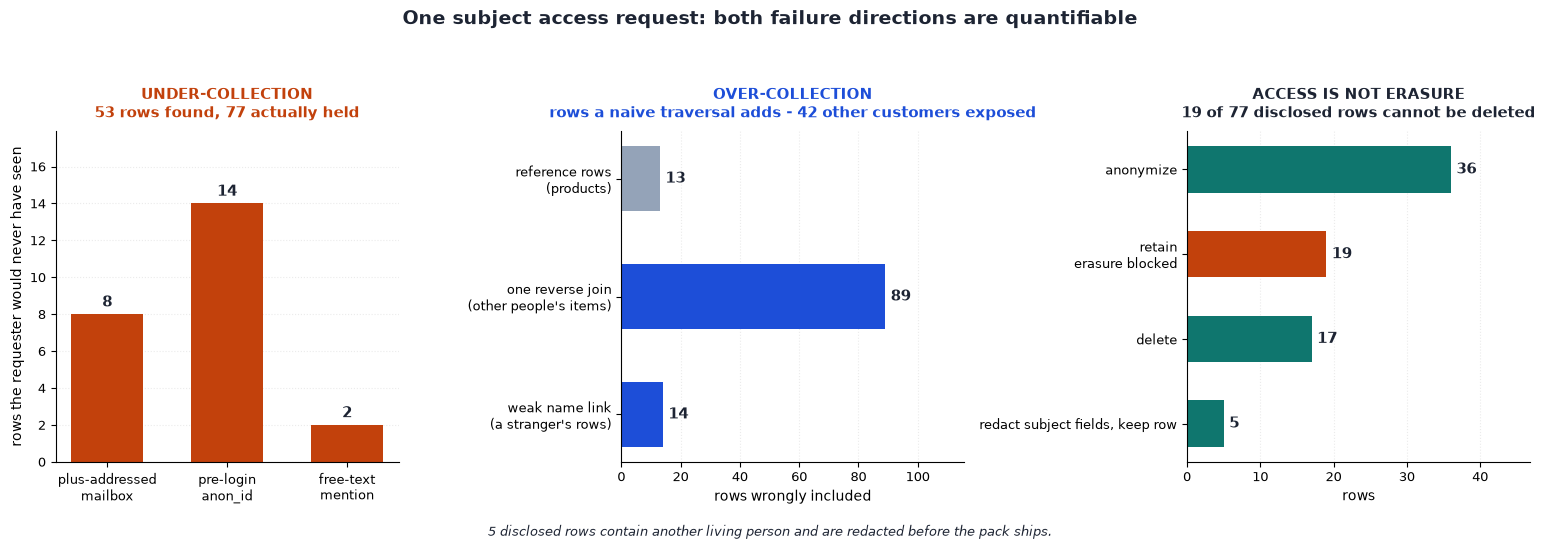

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

INK, UNDER, OVER, OK, MUTED = "#1d2433", "#c2410c", "#1d4ed8", "#0f766e", "#94a3b8"
cost = weak_link_cost(corpus, ident)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4))
fig.suptitle("One subject access request: both failure directions are quantifiable",
             fontsize=14, fontweight="bold", color=INK, y=0.99)

by_mech = {"plus-addressed\nmailbox": 0, "pre-login\nanon_id": 0, "free-text\nmention": 0}
for hit in missed:
    if hit.how == MENTION:
        by_mech["free-text\nmention"] += 1
    elif hit.table == "web_events":
        by_mech["pre-login\nanon_id"] += 1
    else:
        by_mech["plus-addressed\nmailbox"] += 1

ax = axes[0]
bars = ax.bar(list(by_mech), list(by_mech.values()), color=UNDER, width=0.6)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=11, fontweight="bold", color=INK)
ax.set_title(f"UNDER-COLLECTION\n{cov['naive']} rows found, {cov['resolved']} actually held",
             fontsize=11, color=UNDER, fontweight="bold", pad=10)
ax.set_ylabel("rows the requester would never have seen")
ax.set_ylim(0, max(by_mech.values()) * 1.28)

ax = axes[1]
over = {
    "reference rows\n(products)": sweep["products"],
    "one reverse join\n(other people's items)": sweep["_reverse_order_items"],
    "weak name link\n(a stranger's rows)": cost["orders"] + cost["payments"] + cost["order_items"],
}
bars = ax.barh(list(over), list(over.values()), color=[MUTED, OVER, OVER], height=0.55)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=11, fontweight="bold", color=INK)
ax.set_title(f"OVER-COLLECTION\nrows a naive traversal adds - {sweep['_reverse_customers']} "
             "other customers exposed", fontsize=11, color=OVER, fontweight="bold", pad=10)
ax.set_xlabel("rows wrongly included")
ax.set_xlim(0, max(over.values()) * 1.3)
ax.invert_yaxis()

ax = axes[2]
order = [a for a, _ in counts.most_common()]
bars = ax.barh([a.replace(" - ", "\n") for a in order], [counts[a] for a in order],
               color=[UNDER if a == RETAIN else OK for a in order], height=0.55)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=11, fontweight="bold", color=INK)
ax.set_title(f"ACCESS IS NOT ERASURE\n{counts[RETAIN]} of {len(hits)} disclosed rows cannot be deleted",
             fontsize=11, color=INK, fontweight="bold", pad=10)
ax.set_xlabel("rows")
ax.set_xlim(0, max(counts.values()) * 1.3)
ax.invert_yaxis()

for i, ax in enumerate(axes):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(axis="y" if i == 0 else "x", alpha=0.25, linestyle=":")
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=9)

fig.text(0.5, 0.015,
         f"{cov['shared']} disclosed rows contain another living person and are redacted before the pack ships.",
         ha="center", fontsize=9.5, color=INK, style="italic")
fig.tight_layout(rect=(0, 0.045, 1, 0.94))
plt.show()

### The per-table pack

What actually ships, and how each row was reached.

In [16]:
print(summarize(corpus, ident, hits))

IDENTITY
   seed    email        amara.osei@example.com             supplied on the request form
   exact   customer_id  C0001                              customers.email = 'Amara.Osei@Example.com'
   exact   phone        +65 8100 4417                      customers.phone on C0001
   linked  anon_id      anon-9f3c21                        identity_links: device stitched on 2023-03-14 (login on same device)
   linked  anon_id      anon-4b70de                        identity_links: device stitched on 2024-04-11 (email click-through)
 ! weak    customer_id  C0047                              same full_name 'Amara Osei', different mailbox (a.osei@other-example.com) - needs a human decision

STORED SPELLINGS OF THE SAME MAILBOX (what an exact match misses)
   customers.email = 'Amara.Osei@Example.com' -> amara.osei@example.com
   support_tickets.requester_email = 'amara.osei+support@example.com' -> amara.osei@example.com
   support_tickets.requester_email = 'amara.osei+shop@example.com' ->

## 9. Try your own subject map

The engine is generic; the map is the part you replace. For a real warehouse, declare each
table once:

- **which columns identify the subject** (`keys`) and which name the *other* party (`role="counterparty"`)
- **how the table inherits scope** (`scoped_via`) - the only edges the walk follows
- **whether it is reference data** (`category="reference"`) - the walk stops
- **which free-text columns to sweep** (`text_cols`)
- **what erasure means for it** (`delete` / `anonymize` / `redact`) and any statutory `retention`

Everything else - resolution, abstention, redaction, the erasure plan - follows from that
declaration.

In [17]:
# ---------------------------------------------------------------------------------
# Sketch of a real map. Uncomment, point it at your own tables, and the four
# mechanisms come along unchanged.
# ---------------------------------------------------------------------------------
#
# MY_MAP = (
#     TableSpec("dim_customer", "customer_sk",
#               keys=(KeyCol("email_address", "email"),
#                     KeyCol("customer_sk", "customer_id"),
#                     KeyCol("mobile", "phone"))),
#
#     TableSpec("fct_invoice", "invoice_id",
#               keys=(KeyCol("customer_sk", "customer_id"),),
#               fks=(("customer_sk", "dim_customer", "customer_sk"),),
#               retention=Retention("Tax: 7 years from invoice date", 7, "invoice_date")),
#
#     TableSpec("dim_product", "product_sk", category="reference"),   # walk stops here
#
#     TableSpec("crm_note", "note_id",
#               keys=(KeyCol("author_email", "email"),),
#               text_cols=("note_body",),                            # swept for mentions
#               erasure="redact"),
# )
#
# Then, on your own data:
#
# my_corpus = {"dim_customer": rows_from_your_query, ...}
# ident = resolve_identity(my_corpus, "requester@example.com")
#
# # Review the abstained links BEFORE extracting - this is a human decision.
# for key in ident.weak:
#     print("needs a decision:", key.key_type, key.value, "-", key.evidence)
#
# hits = extract(my_corpus, ident)
# pack = disclosure_pack(my_corpus, ident, hits)       # redacted, safe to send
# plan = erasure_plan(hits, my_corpus)                 # a different set of rows
#
# # Ship nothing that still carries a third party.
# assert not any(h.shared and "@" in str(redact(h, ident, my_corpus)) for h in [])

---

**Streamlit version** - change the identifier, move the retention date, and watch the
disclosure pack, the withheld rows and the erasure plan change:

```bash
pip install -r requirements.txt
streamlit run app.py
```

**Tests** - the four guarantees, asserted:

```bash
python3 test_dsar.py
```

Nothing here is legal advice. Article and section numbers are cited so a privacy counsel
can check the mapping against your own obligations.

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) · [`data-quality-governance/dsar-extractor`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/dsar-extractor)